In [1]:
import random
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt

# I. The Axelrod Model of Cultural Dynamics or the network model based on it

The model defined on a network $G = (V, E)$ with $N = |V|$ agents (nodes). Each agent $i$ is characterized by a cultural vector that represents its positions on a number of subjects:

$\sigma_i = (\sigma_i^1, \sigma_i^2, ..., \sigma_i^F)$

where

- $F$: number of features (e.g., cultural attributes)
- $q$: number of possible positions per subject, thus $\sigma_i^f \in \{1, 2, ..., q\}$
## Initialization
For each agent $i$ and feature $f$, assign $\sigma_i^f$ uniformly at random from $\{1, ..., q\}$.

## Dynamics (One Time Step)
1. Select a random edge $(i, j) \in E$ (or pick a random node and one of its neighbors).
2. Compute similarity (overlap) of the interacting partners:
$$
\omega_{ij}=\frac{1}{F}\sum_{f=1}^F=\delta(\sigma^f_i,\sigma^f_j),
$$
where $\delta = 1$ if traits are equal, $0$ otherwise.

3. With probability $\omega_{ij}$, the selected agents interact: one agent convinces its partner about a particular subject
- Select a feature $f$ where $\sigma_i^f \neq \sigma_j^f$
- Update: $\sigma_i^f \leftarrow \sigma_j^f$
(Optionally, choose update direction at random.)

## Parameters
- $N$: number of agents (e.g., 100–1000)
- $F$: number of features (e.g., 5–10)
- $q$: number of traits (e.g., 2–10)
- **Network topology**: Watts-Strogratz graph, with various values of $p$ 

## Stopping Condition
The system reaches a steady state when no active edges remain. Thus, for every edge (i, j):

- Either $\omega_{ij} = 0$ (no similarity → no interaction is possible)
- Or $\omega_{ij} = 1$ (identical → no further change is possible)

## Observables
- Number of distinct cultures (unique $\sigma_i$)
- Size of the largest cultural domain
- Plot the above quantities as function of p

# II. Simulate the Homophily based Kumpula model
Recreate the Kumpula model with different aging mechanisms and detect the communities

1. Start with $N$ unconnected nodes, which have $F$ each of which can have $q$ distinct trait values
2. For each node $i$ execute the following steps:
    1. Select a feature $f$ 
    2. With probability $pr$ choose a random $j$ from the nodes which have the same trait value at feature $f$ and create a connection between $i$ and $j$ with weight $w[i,j]=1$
    3. choose $j$ a neighbor of $i$ with mathcing feature $f$ with probability proportional to $w[i,j]$ (if $i$ has no neighbor then create a random one), choose $k$, different from $i$, a neighbor of $j$ with mathcing feature $f$ with probability proportional to $w[j,k]$ (if $j$ has no other neighbor than $i$ then create a random one). Increase the weights, $w[i,j]$, $w[j,k]$ by $1$, if the connection $i,k$ exists increase also $w[i,k]$ by one, if the connection $i,k$ does not exist then create it with probability pt with unit weight.
3. **Link aging**: After all nodes were considered in the previous step, execute one of the following Multiply all links with la which is a positive number and less than one.
Plot the resulting graph.

# I. Axelrod Model

In [ ]:
class AxelrodModel:
    def __init__(self, N=100, F=5, q=5, k=4, p=0.1, seed=None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)

        self.N = N
        self.F = F
        self.q = q
        self.history_largest_domain = []
        self.history_num_cultures = []
        self.history_domain_sizes = []
        self.G = ig.Graph.Watts_Strogatz(1, N, k, p)
        self.sigma = np.random.randint(1, q + 1, size=(N, F))

    def similarity(self, i, j):
        """Compute ω_ij"""
        return np.mean(self.sigma[i] == self.sigma[j])

    def step(self):
        """One interaction step"""
        edge = random.choice(self.G.es)
        i, j = edge.tuple

        # compute similarity
        omega = self.similarity(i, j)

        # interact with probability omega
        if omega > 0 and omega < 1 and random.random() < omega:
            # find differing features
            diff = np.where(self.sigma[i] != self.sigma[j])[0]
            if len(diff) > 0:
                f = random.choice(diff)

                # random direction
                if random.random() < 0.5:
                    self.sigma[i, f] = self.sigma[j, f]
                else:
                    self.sigma[j, f] = self.sigma[i, f]

    def active_edges_exist(self):
        """Check stopping condition"""
        for edge in self.G.es:
            i, j = edge.tuple
            omega = self.similarity(i, j)
            if 0 < omega < 1:
                return True
        return False

    def run(self, max_steps=100000, record_every=100):
        steps = 0

        while self.active_edges_exist() and steps < max_steps:
            self.step()
            steps += 1

            if steps % record_every == 0:
                self.history_largest_domain.append(self.largest_domain_size())
                self.history_num_cultures.append(self.count_cultures())
                self.history_domain_sizes.append(self.get_domain_sizes().tolist())

        self.history_largest_domain.append(self.largest_domain_size())
        self.history_num_cultures.append(self.count_cultures())
        self.history_domain_sizes.append(self.get_domain_sizes().tolist())

        return steps

    def count_cultures(self):
        """Number of distinct cultural vectors"""
        unique = np.unique(self.sigma, axis=0)
        return len(unique)
    
    def get_domain_sizes(self):
        """Sizes of all cultural clusters"""
        _, counts = np.unique(self.sigma, axis=0, return_counts=True)
        return counts

    def largest_domain_size(self):
        """Size of largest cultural cluster"""
        return np.max(self.get_domain_sizes())

In [46]:
model = AxelrodModel(N=100, F=8, q=8, k=4, p=0.0, seed=42)

steps = model.run()

print("Steps:", steps)
print("Number of cultures:", model.count_cultures())
print("Largest domain:", model.largest_domain_size())

Steps: 100000
Number of cultures: 2
Largest domain: 77


In [47]:
max(model.history_domain_sizes[100])

12

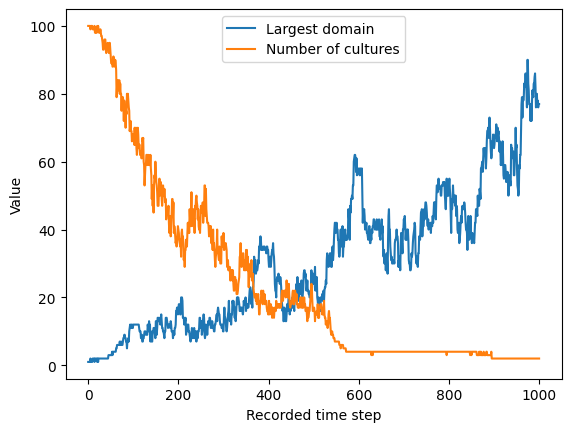

In [48]:
plt.plot(model.history_largest_domain, label="Largest domain")
plt.plot(model.history_num_cultures, label="Number of cultures")

plt.xlabel("Recorded time step")
plt.ylabel("Value")
plt.legend()
plt.show()

In [49]:
model.get_domain_sizes()

array([77, 23])

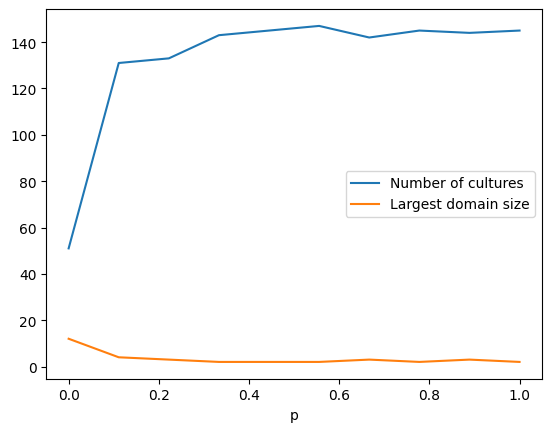

In [50]:
ps = np.linspace(0, 1, 10)

num_cultures = []
largest_domains = []

for p in ps:
    model = AxelrodModel(N=150, F=10, q=10, k=4, p=p, seed=42)
    model.run()

    num_cultures.append(model.count_cultures())
    largest_domains.append(model.largest_domain_size())

# Plot
plt.figure()
plt.plot(ps, num_cultures, label="Number of cultures")
plt.plot(ps, largest_domains, label="Largest domain size")
plt.xlabel("p")
plt.legend()
plt.show()

# II. Kumpula model

In [ ]:
import numpy as np
import igraph as ig
import random

class KumpulaModel:
    def __init__(self, N=100, F=5, q=5, pr=0.01, pt=0.5, la=0.9, seed=None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)

        self.N = N
        self.F = F
        self.q = q
        self.pr = pr
        self.pt = pt
        self.la = la

        # empty graph
        self.G = ig.Graph()
        self.G.add_vertices(N)

        # ensure weight attribute exists
        self.G.es["weight"] = []

        # traits
        self.sigma = np.random.randint(1, q + 1, size=(N, F))

    def same_feature_nodes(self, i, f):
        nodes = np.where(self.sigma[:, f] == self.sigma[i, f])[0]
        return nodes[nodes != i]

    def weighted_choice(self, neighbors, weights):
        if len(neighbors) == 0:
            return None
        weights = np.array(weights, dtype=float)
        if weights.sum() == 0:
            return random.choice(neighbors)
        probs = weights / weights.sum()
        return np.random.choice(neighbors, p=probs)

    def add_or_increment_edge(self, i, j):
        if i == j:
            return

        eid = self.G.get_eid(i, j, directed=False, error=False)

        if eid == -1:
            self.G.add_edge(i, j, weight=1.0)
        else:
            self.G.es[eid]["weight"] += 1.0

    def step_node(self, i):
        f = random.randrange(self.F)

        # ---- (1) Random link formation ----
        if random.random() < self.pr:
            candidates = self.same_feature_nodes(i, f)
            if len(candidates) > 0:
                j = random.choice(candidates)
                self.add_or_increment_edge(i, j)

        # ---- (2) Triadic closure ----
        neighbors_i = self.G.neighbors(i)

        # filter by matching feature
        neighbors_i = [j for j in neighbors_i if self.sigma[j, f] == self.sigma[i, f]]

        if len(neighbors_i) == 0:
            candidates = self.same_feature_nodes(i, f)
            if len(candidates) > 0:
                j = random.choice(candidates)
                self.add_or_increment_edge(i, j)
            return

        weights_i = [self.G.es[self.G.get_eid(i, j)]["weight"] for j in neighbors_i]
        j = self.weighted_choice(neighbors_i, weights_i)

        neighbors_j = self.G.neighbors(j)
        neighbors_j = [k for k in neighbors_j if k != i and self.sigma[k, f] == self.sigma[j, f]]

        if len(neighbors_j) == 0:
            candidates = self.same_feature_nodes(j, f)
            if len(candidates) > 0:
                k = random.choice(candidates)
                self.add_or_increment_edge(j, k)
            return

        weights_j = [self.G.es[self.G.get_eid(j, k)]["weight"] for k in neighbors_j]
        k = self.weighted_choice(neighbors_j, weights_j)

        # ---- reinforcement ----
        self.add_or_increment_edge(i, j)
        self.add_or_increment_edge(j, k)

        # ---- triadic closure ----
        eid_ik = self.G.get_eid(i, k, error=False)
        if eid_ik != -1:
            self.G.es[eid_ik]["weight"] += 1.0
        else:
            if random.random() < self.pt:
                self.G.add_edge(i, k, weight=1.0)

    def aging(self, age_threshold=0.01):
        if len(self.G.es) == 0:
            return

        if "weight" not in self.G.es.attributes():
            self.G.es["weight"] = [1.0] * len(self.G.es)

        weights = np.array(self.G.es["weight"], dtype=float)
        weights *= self.la
        self.G.es["weight"] = weights.tolist()

        # remove weak edges
        to_delete = [e.index for e in self.G.es if e["weight"] < age_threshold]
        if len(to_delete) > 0:
            self.G.delete_edges(to_delete)

    def step(self, age_threshold=0.01):
        for i in range(self.N):
            self.step_node(i)
        self.aging(age_threshold)

    def run(self, steps=100, age_threshold=0.01):
        for _ in range(steps):
            self.step(age_threshold)

In [88]:
model = KumpulaModel(
    N=150,
    F=3,
    q=4,        
    pr=0.05,    
    pt=0.25,    
    la=0.15,    
    seed=42
)

model.run(steps=500)

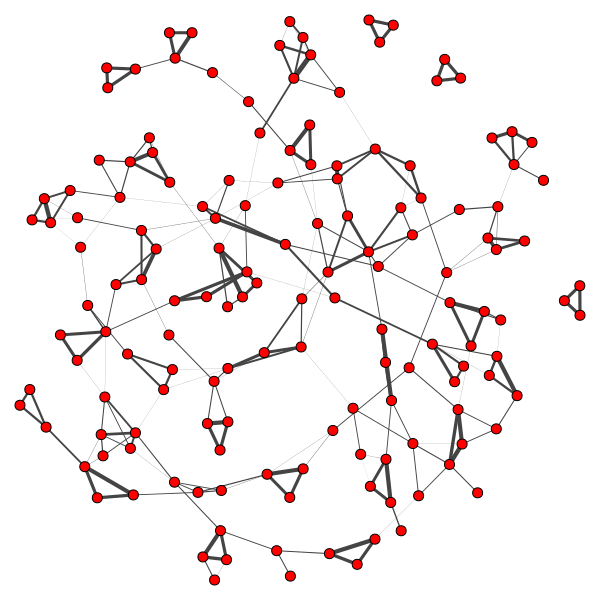

In [89]:
layout = model.G.layout("fr")  # force-directed

weights = model.G.es["weight"]
scaled_weights = np.array([w * 2 for w in weights]) 
scaled_weights /= np.max(scaled_weights)
scaled_weights *= 5

ig.plot(
    model.G,
    layout=layout,
    vertex_size=10,
    edge_width=scaled_weights
)

In [50]:
communities = model.G.community_multilevel(weights="weight",
                                           resolution=0.75)

print("Number of communities:", len(communities))
print("Sizes:", communities.sizes())

Number of communities: 11
Sizes: [12, 5, 19, 8, 15, 8, 4, 3, 10, 11, 5]


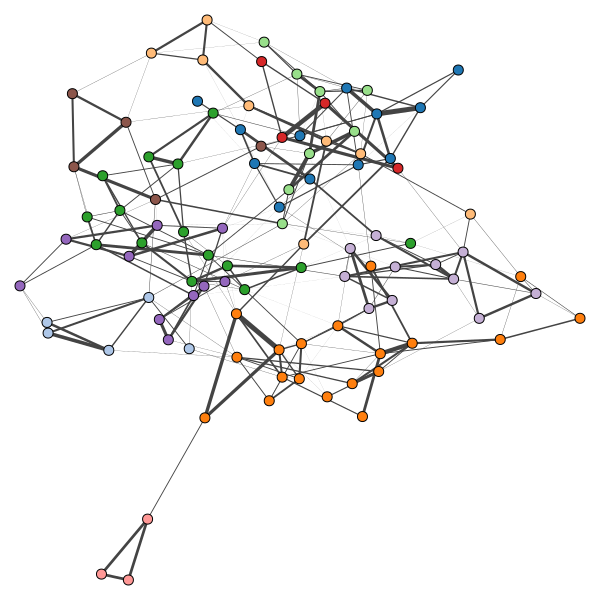

In [51]:
colors = communities.membership
cmap = plt.get_cmap("tab20")
colors = [cmap(i % 20) for i in colors]
ig.plot(
    model.G,
    layout=layout,
    vertex_color=colors,
    vertex_size=10,
    edge_width=scaled_weights
)